This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of
2010.

(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/Weekly.csv"
Weekly = pd.read_csv(url)

Weekly['Direction'] = Weekly['Direction'].astype('category')

print(Weekly.head())
print(Weekly.shape)




   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up
(1089, 9)


               Year         Lag1         Lag2         Lag3         Lag4  \
count   1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean    2000.048669     0.150585     0.151079     0.147205     0.145818   
std        6.033182     2.357013     2.357254     2.360502     2.360279   
min     1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%     1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%     2000.000000     0.241000     0.241000     0.241000     0.238000   
75%     2005.000000     1.405000     1.409000     1.409000     1.409000   
max     2010.000000    12.026000    12.026000    12.026000    12.026000   

               Lag5       Volume        Today Direction  
count   1089.000000  1089.000000  1089.00

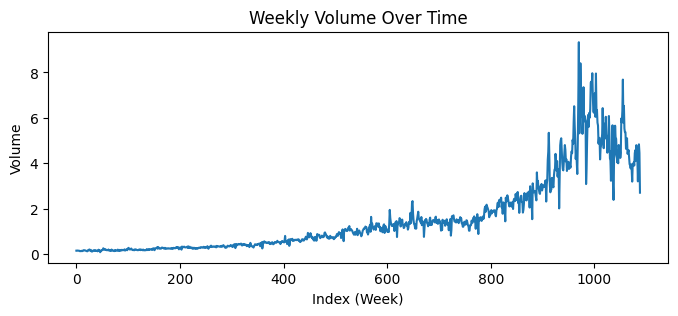

In [2]:
import matplotlib.pyplot as plt

print(Weekly.describe(include='all'))

Weekly['Volume'].plot(title="Weekly Volume Over Time", figsize=(8,3))
plt.xlabel("Index (Week)")
plt.ylabel("Volume")
plt.show()


(b) Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume
as predictors. Use the summary function to print the results. Do
any of the predictors appear to be statistically significant? If so,
which ones?

In [4]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

fit_full = smf.glm('Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume',
                   data=Weekly, family=sm.families.Binomial()).fit()
print(fit_full.summary())


                          Generalized Linear Model Regression Results                           
Dep. Variable:     ['Direction[Down]', 'Direction[Up]']   No. Observations:                 1089
Model:                                              GLM   Df Residuals:                     1082
Model Family:                                  Binomial   Df Model:                            6
Link Function:                                    Logit   Scale:                          1.0000
Method:                                            IRLS   Log-Likelihood:                -743.18
Date:                                  Sun, 09 Nov 2025   Deviance:                       1486.4
Time:                                          09:59:50   Pearson chi2:                 1.09e+03
No. Iterations:                                       4   Pseudo R-squ. (CS):           0.009000
Covariance Type:                              nonrobust                                         
                 coef    std e

(c) Compute the confusion matrix and overall fraction of correct
predictions. Explain what the confusion matrix is telling you
about the types of mistakes made by logistic regression.

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

prob = fit_full.predict(Weekly)
pred = np.where(prob > 0.5, 'Up', 'Down')

cm = confusion_matrix(Weekly['Direction'], pred)
acc = accuracy_score(Weekly['Direction'], pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)


Confusion Matrix:
 [[430  54]
 [557  48]]
Accuracy: 0.4389348025711662


(d) Now fit the logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 and 2010).

In [6]:
train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

fit_lag2 = smf.glm('Direction ~ Lag2', data=train, family=sm.families.Binomial()).fit()
prob_te = fit_lag2.predict(test)
pred_te = np.where(prob_te > 0.5, 'Up', 'Down')

cm_te = confusion_matrix(test['Direction'], pred_te)
acc_te = accuracy_score(test['Direction'], pred_te)

print("Confusion Matrix (Lag2):\n", cm_te)
print("Test Accuracy:", acc_te)


Confusion Matrix (Lag2):
 [[34  9]
 [56  5]]
Test Accuracy: 0.375


(e) Repeat (d) using LDA.

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(train[['Lag2']], train['Direction'])
pred_lda = lda.predict(test[['Lag2']])

cm_lda = confusion_matrix(test['Direction'], pred_lda)
acc_lda = accuracy_score(test['Direction'], pred_lda)
print("LDA Confusion Matrix:\n", cm_lda)
print("LDA Accuracy:", acc_lda)


LDA Confusion Matrix:
 [[ 9 34]
 [ 5 56]]
LDA Accuracy: 0.625


(f) Repeat (d) using QDA.

In [8]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(train[['Lag2']], train['Direction'])
pred_qda = qda.predict(test[['Lag2']])

cm_qda = confusion_matrix(test['Direction'], pred_qda)
acc_qda = accuracy_score(test['Direction'], pred_qda)
print("QDA Confusion Matrix:\n", cm_qda)
print("QDA Accuracy:", acc_qda)


QDA Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
QDA Accuracy: 0.5865384615384616


(g) Repeat (d) using KNN with K = 1.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(train[['Lag2']], train['Direction'])
pred_knn1 = knn1.predict(test[['Lag2']])

cm_knn1 = confusion_matrix(test['Direction'], pred_knn1)
acc_knn1 = accuracy_score(test['Direction'], pred_knn1)
print("KNN (k=1) Confusion Matrix:\n", cm_knn1)
print("KNN (k=1) Accuracy:", acc_knn1)


KNN (k=1) Confusion Matrix:
 [[22 21]
 [32 29]]
KNN (k=1) Accuracy: 0.49038461538461536


(h) Repeat (d) using naive Bayes.

In [10]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(train[['Lag2']], train['Direction'])
pred_nb = nb.predict(test[['Lag2']])

cm_nb = confusion_matrix(test['Direction'], pred_nb)
acc_nb = accuracy_score(test['Direction'], pred_nb)
print("Naive Bayes Confusion Matrix:\n", cm_nb)
print("Naive Bayes Accuracy:", acc_nb)


Naive Bayes Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Naive Bayes Accuracy: 0.5865384615384616


(i) Which of these methods appears to provide the best results on
this data?

In [11]:
import pandas as pd

summary = pd.DataFrame({
    'Model': ['GLM (Lag2)','LDA (Lag2)','Naive Bayes (Lag2)','QDA (Lag2)','KNN k=1 (Lag2)'],
    'Accuracy': [acc_te, acc_lda, acc_nb, acc_qda, acc_knn1]
}).sort_values('Accuracy', ascending=False)

print(summary)


                Model  Accuracy
1          LDA (Lag2)  0.625000
3          QDA (Lag2)  0.586538
2  Naive Bayes (Lag2)  0.586538
4      KNN k=1 (Lag2)  0.490385
0          GLM (Lag2)  0.375000


(j) Experiment with different combinations of predictors, including possible transformations and interactions, for each of the
methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held
out data. Note that you should also experiment with values for
K in the KNN classifier.

In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import statsmodels.formula.api as smf
import statsmodels.api as sm
from itertools import combinations



train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

results = []


# 1. Logistic regression
predictors_list = [
    ['Lag2'],
    ['Lag1', 'Lag2'],
    ['Lag2', 'Lag2_sq'],  # Add Lag2 squared term
    ['Lag1', 'Lag2', 'Volume'],
]

# Add squared terms
train['Lag2_sq'] = train['Lag2'] ** 2
test['Lag2_sq'] = test['Lag2'] ** 2

for preds in predictors_list:
    formula = "Direction ~ " + " + ".join(preds)
    fit = smf.glm(formula, data=train, family=sm.families.Binomial()).fit()
    pred = np.where(fit.predict(test) > 0.5, 'Up', 'Down')
    acc = accuracy_score(test['Direction'], pred)
    results.append({
        'Model': 'Logistic',
        'Predictors': preds,
        'Accuracy': acc,
        'Confusion': confusion_matrix(test['Direction'], pred)
    })


# 2. LDA / QDA
for preds in [['Lag2'], ['Lag1', 'Lag2'], ['Lag2', 'Volume']]:
    lda = LinearDiscriminantAnalysis()
    lda.fit(train[preds], train['Direction'])
    pred_lda = lda.predict(test[preds])
    results.append({
        'Model': 'LDA',
        'Predictors': preds,
        'Accuracy': accuracy_score(test['Direction'], pred_lda),
        'Confusion': confusion_matrix(test['Direction'], pred_lda)
    })

    qda = QuadraticDiscriminantAnalysis()
    qda.fit(train[preds], train['Direction'])
    pred_qda = qda.predict(test[preds])
    results.append({
        'Model': 'QDA',
        'Predictors': preds,
        'Accuracy': accuracy_score(test['Direction'], pred_qda),
        'Confusion': confusion_matrix(test['Direction'], pred_qda)
    })

# 3. KNN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train[['Lag2']])
X_test = scaler.transform(test[['Lag2']])
y_train = train['Direction']

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_knn = knn.predict(X_test)
    results.append({
        'Model': f'KNN (k={k})',
        'Predictors': ['Lag2'],
        'Accuracy': accuracy_score(test['Direction'], pred_knn),
        'Confusion': confusion_matrix(test['Direction'], pred_knn)
    })

# 4. Naive Bayes
for preds in [['Lag2'], ['Lag1', 'Lag2'], ['Lag2', 'Volume']]:
    nb = GaussianNB()
    nb.fit(train[preds], train['Direction'])
    pred_nb = nb.predict(test[preds])
    results.append({
        'Model': 'Naive Bayes',
        'Predictors': preds,
        'Accuracy': accuracy_score(test['Direction'], pred_nb),
        'Confusion': confusion_matrix(test['Direction'], pred_nb)
    })



df_results = pd.DataFrame(results)
best = df_results.loc[df_results['Accuracy'].idxmax()]

print("Optimal Model")
print(best)


/tmp/ipython-input-1901802587.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Lag2_sq'] = train['Lag2'] ** 2
/tmp/ipython-input-1901802587.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Lag2_sq'] = test['Lag2'] ** 2


Optimal Model
Model                        LDA
Predictors                [Lag2]
Accuracy                   0.625
Confusion     [[9, 34], [5, 56]]
Name: 4, dtype: object
